# Correlation Analysis: IC Accessibility & Socio-Economic Indicators in Switzerland

This notebook serves as the primary data processing pipeline for the D3.js interactive dashboard. It merges geographical boundaries, performs precise spatial routing analysis, and correlates intercity (IC) transport accessibility with municipal socio-economic factors.

### Generated D3.js Visualizations:
1. **The Accessibility Paradox:** Scatter plot analyzing travel time vs. real estate prices.
2. **Employment Hubs Connectivity:** Bar chart comparing average travel times across cantons.
3. **Wealth Gaps vs. Mobility:** Scatter plot correlating taxable income and IC accessibility.
4. **The Density Trade-off:** Log-scale scatter plot exploring population density versus transit times.

### Data Architecture & Sources:
* **Spatial Boundaries:** Official FSO registry and K4 municipal polygons (`Boundaries_K4_Commune_20260101.gpkg`).
* **Transit Accessibility:** Geospatial routing points mapping the Swiss public transport network (`accessibility_1200_240min.geojson`).
* **Socio-Economic Layers:** Curated datasets for real estate, income, employment, and demographics generated by the upstream mapping pipeline.

### Methodology:
Instead of relying on proxy estimates, true accessibility is calculated via **spatial joins** (`geopandas`). The pipeline superimposes IC travel time coordinates onto official municipal boundaries to calculate accurate local averages. Missing data points are resolved using nearest-neighbor geospatial projection (LV95/EPSG:2056). Bivariate correlations are then evaluated using Pearson's *r* to uncover statistical relationships between regional connectivity and urban development metrics.

In [72]:
import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics for inline notebook rendering
sns.set_theme(style="whitegrid")

# Define and create the output directory for D3.js web assets
output_dir = Path('../docs/data/correlations')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Directory ready for web exports: {output_dir.absolute()}")

Directory ready for web exports: /Users/matthiaswyss/Documents/EPFL/2025-26/MA4/COM-480 Data Visualization/les-vizionnaires.worktrees/agents-analysis-correlation-graphs-d3js/notebooks/../docs/data/correlations


In [73]:
def load_geojson_features(file_path):
    """Utility function to extract features from a GeoJSON file."""
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)['features']

print("Loading official Swiss municipal datasets...")

# Load individual data layers exported from the mapping pipeline
re_features = load_geojson_features('../docs/data/real_estate_prices.geojson')
inc_features = load_geojson_features('../docs/data/income_levels.geojson')
job_features = load_geojson_features('../docs/data/municipal_jobs.geojson')
dens_features = load_geojson_features('../docs/data/population_density.geojson')
pt_features = load_geojson_features('../docs/data/public_transport_share.geojson')

# Convert JSON features into fast-lookup dictionaries using municipal names as keys
real_estate = {feat['properties']['name']: feat['properties'] for feat in re_features}
income = {feat['properties']['name']: feat['properties'] for feat in inc_features}
jobs = {feat['properties']['name']: feat['properties'] for feat in job_features}
density = {feat['properties']['name']: feat['properties'] for feat in dens_features}
pt_share = {feat['properties']['name']: feat['properties'] for feat in pt_features}

print("\n--- Data Ingestion Summary ---")
print(f"Real Estate : {len(real_estate)} municipalities")
print(f"Income      : {len(income)} municipalities")
print(f"Jobs        : {len(jobs)} municipalities")
print(f"Density     : {len(density)} municipalities")
print(f"PT Share    : {len(pt_share)} municipalities")

Loading official Swiss municipal datasets...

--- Data Ingestion Summary ---
Real Estate : 2123 municipalities
Income      : 2110 municipalities
Jobs        : 2110 municipalities
Density     : 2105 municipalities
PT Share    : 2123 municipalities


In [74]:
print("Initializing geospatial routing analysis...")

# 1. Load spatial layers
points_path = Path('../docs/data/ptA_IC/accessibility_1200_240min.geojson')
gdf_points = gpd.read_file(points_path)

# Use the official K4 boundary definitions to ensure precise spatial mapping
boundaries_path = Path('../data/Boundaries_K4_Commune_20260101.gpkg')
gdf_communes = gpd.read_file(boundaries_path)

# Standardize municipal names to match the primary tabular datasets
gdf_communes['name'] = gdf_communes['GDENAME'].astype(str).str.strip().str.title()

# Align Coordinate Reference Systems (CRS) before performing geometric operations
if gdf_points.crs != gdf_communes.crs:
    gdf_points = gdf_points.to_crs(gdf_communes.crs)

# 2. Primary Spatial Join (Points contained within municipal polygons)
joined_intersect = gpd.sjoin(gdf_points, gdf_communes, how="inner", predicate="intersects")

# Aggregate routing metrics for municipalities with internal transit nodes
communes_avec_points = joined_intersect.groupby('name').agg({
    'min_travel_time_to_ic': 'mean',
    'n_destinations_reachable': 'mean'
}).reset_index()

# 3. Handle 'Empty' Municipalities (Nearest-neighbor fallback)
communes_manquantes = set(gdf_communes['name']) - set(communes_avec_points['name'])
gdf_communes_vides = gdf_communes[gdf_communes['name'].isin(communes_manquantes)].copy()

# Project to Swiss LV95 (EPSG:2056) to calculate accurate metric distances
gdf_points_ch = gdf_points.to_crs(epsg=2056)
gdf_communes_vides_ch = gdf_communes_vides.to_crs(epsg=2056)

joined_nearest = gpd.sjoin_nearest(gdf_communes_vides_ch, gdf_points_ch, how="left", distance_col="distance_m")
communes_nearest = joined_nearest[['name', 'min_travel_time_to_ic', 'n_destinations_reachable']].drop_duplicates(subset=['name'])

# 4. Final Data Consolidation
df_accessibilite = pd.concat([communes_avec_points, communes_nearest], ignore_index=True)
df_accessibilite['avg_travel_time_ic'] = df_accessibilite['min_travel_time_to_ic'].round(1)
df_accessibilite['avg_destinations'] = df_accessibilite['n_destinations_reachable'].round().astype(int)

# Create the master dictionary for the analytical pipeline
access_dict = df_accessibilite.set_index('name')[['avg_travel_time_ic', 'avg_destinations']].to_dict('index')

print(f"✅ Geospatial routing complete: {len(access_dict)} municipal times calculated.")

Initializing geospatial routing analysis...
✅ Geospatial routing complete: 2110 municipal times calculated.


In [75]:
# 1. Load the official FSO (OFS) registry for accurate canton mapping
mapping_df = pd.read_excel('../data/EtatCommunes.xlsx')
canton_dict = dict(zip(mapping_df['Nom de la commune'], mapping_df['Canton']))

print("Compiling final analytical dataset...")
data_list = []

# Iterate through the verified accessibility dictionary
for muni, access_data in access_dict.items():
    
    canton = canton_dict.get(muni)
    
    # Ignore entry if the municipality is not recognized by the official registry
    if not canton:
        continue 
        
    travel_time = access_data.get('avg_travel_time_ic')
    
    # Ignore entry if the routing time is mathematically invalid
    if pd.isna(travel_time):
        continue

    # Compile the comprehensive municipal profile
    row = {
        'name': muni,
        'canton': canton,
        'canton_code': canton,
        'avg_travel_time_ic': float(travel_time),
        'avg_destinations': int(access_data.get('avg_destinations', 0)),
        'Price_per_m2': real_estate.get(muni, {}).get('Price_per_m2'),
        'Avg_Income': income.get(muni, {}).get('Avg_Income'),
        'Total_Jobs': jobs.get(muni, {}).get('Total_Jobs'),
        'Pop_Density': density.get(muni, {}).get('Pop_Density'),
        'population': density.get(muni, {}).get('Total_Population'),
        'PT_Share': pt_share.get(muni, {}).get('PT_Share', 0.0),
    }
    data_list.append(row)

df = pd.DataFrame(data_list)
print(f"✅ Unified master dataset built: {len(df)} municipalities spanning {df['canton'].nunique()} cantons.")

/Users/matthiaswyss/anaconda3/envs/dataviz/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Compiling final analytical dataset...
✅ Unified master dataset built: 1830 municipalities spanning 26 cantons.


## Chart 1: Accessibility Paradox (Travel time vs Real Estate price)

--- Chart 1: Accessibility Paradox ---
Pearson r : -0.158 (p-value: 0.0028)
Sample    : 356 municipalities


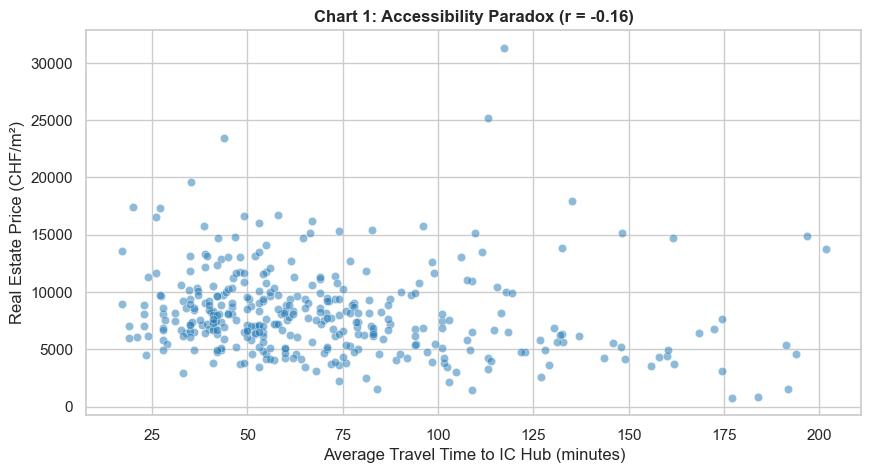

In [76]:
# Filter out records missing critical variables
scatter_df = df[(df['avg_travel_time_ic'].notna()) & 
                (df['Price_per_m2'].notna()) & 
                (df['Price_per_m2'] > 0)].copy()

if len(scatter_df) > 2:
    r1, p1 = pearsonr(scatter_df['avg_travel_time_ic'], scatter_df['Price_per_m2'])
    print("--- Chart 1: Accessibility Paradox ---")
    print(f"Pearson r : {r1:.3f} (p-value: {p1:.4f})")
    print(f"Sample    : {len(scatter_df)} municipalities")
else:
    r1 = None
    print("Insufficient data for correlation analysis.")

# Prepare valid JSON payload (convert NaN to None/null)
export_df1 = scatter_df[['name', 'canton', 'avg_travel_time_ic', 'Price_per_m2', 'Avg_Income']].replace({np.nan: None})

with open(output_dir / 'scatter_accessibility_realestate.json', 'w', encoding='utf-8') as f:
    json.dump({
        'title': 'Accessibility Paradox',
        'n_data': len(scatter_df),
        'correlation': float(r1) if (r1 and not pd.isna(r1)) else None,
        'data': export_df1.to_dict('records')
    }, f)

# Inline Plot Rendering
plt.figure(figsize=(10, 5))
sns.scatterplot(data=scatter_df, x='avg_travel_time_ic', y='Price_per_m2', alpha=0.5, color='#1f77b4')
plt.title(f"Chart 1: Accessibility Paradox (r = {r1:.2f})", fontweight='bold')
plt.xlabel("Average Travel Time to IC Hub (minutes)")
plt.ylabel("Real Estate Price (CHF/m²)")
plt.show()

## Chart 2: Employment Hubs (Average travel time by canton)

--- Chart 2: Employment Hubs ---
Total CantonsAnalyzed : 26
Time Distribution     : 42.6 - 168.2 minutes


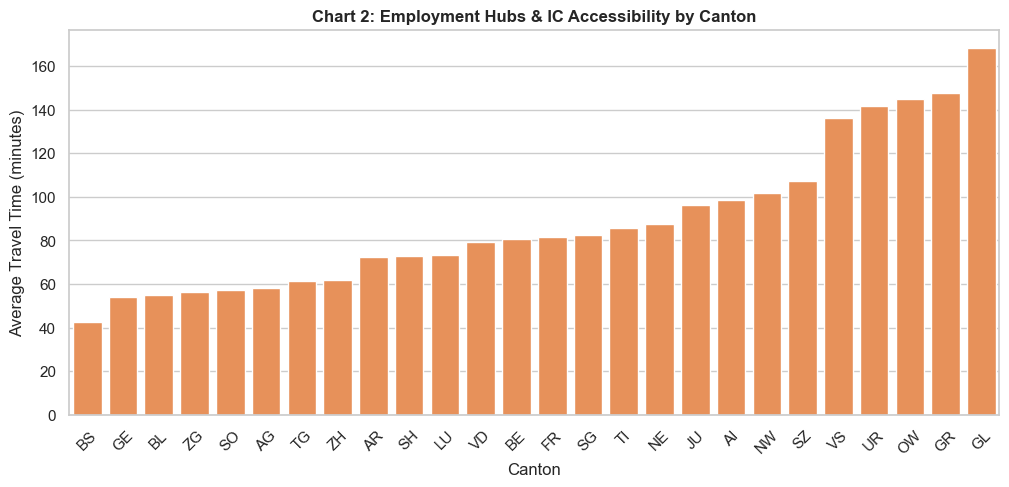

In [77]:
# Aggregate mobility metrics at the cantonal level
canton_travel = df.groupby('canton')['avg_travel_time_ic'].agg(['mean', 'std', 'count']).reset_index()
canton_travel.columns = ['canton', 'avg_travel_time', 'std_dev', 'n_municipalities']
canton_travel = canton_travel.sort_values('avg_travel_time')

print("--- Chart 2: Employment Hubs ---")
print(f"Total CantonsAnalyzed : {len(canton_travel)}")
print(f"Time Distribution     : {canton_travel['avg_travel_time'].min():.1f} - {canton_travel['avg_travel_time'].max():.1f} minutes")

# Prepare valid JSON payload
export_df2 = canton_travel.replace({np.nan: None})

with open(output_dir / 'employment_connectivity.json', 'w', encoding='utf-8') as f:
    json.dump({
        'title': 'Employment Hubs',
        'n_cantons': len(canton_travel),
        'data': export_df2.to_dict('records')
    }, f)

# Inline Plot Rendering
plt.figure(figsize=(12, 5))
sns.barplot(data=canton_travel, x='canton', y='avg_travel_time', color='#ff8c42')
plt.title("Chart 2: Employment Hubs & IC Accessibility by Canton", fontweight='bold')
plt.xlabel("Canton")
plt.ylabel("Average Travel Time (minutes)")
plt.xticks(rotation=45)
plt.show()

## Chart 3: Wealth Gaps (Taxable income vs accessibility by canton)

--- Chart 3: Wealth Gaps ---
Pearson r : -0.538 (p-value: 0.0046)
Sample    : 26 cantons


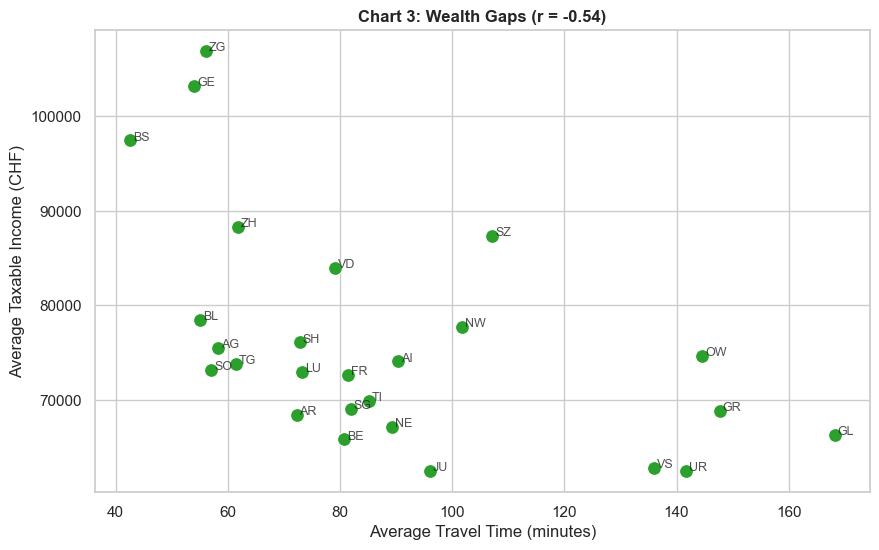

In [78]:
# Aggregate taxable income and mobility at the cantonal level
wealth_df = df[(df['Avg_Income'].notna()) & (df['avg_travel_time_ic'].notna())].copy()
wealth_by_canton = wealth_df.groupby('canton').agg({
    'Avg_Income': 'mean',
    'avg_travel_time_ic': 'mean',
    'name': 'count'
}).reset_index()
wealth_by_canton.columns = ['canton', 'avg_income', 'avg_travel_time', 'n_municipalities']

if len(wealth_by_canton) > 2:
    r3, p3 = pearsonr(wealth_by_canton['avg_income'], wealth_by_canton['avg_travel_time'])
    print("--- Chart 3: Wealth Gaps ---")
    print(f"Pearson r : {r3:.3f} (p-value: {p3:.4f})")
    print(f"Sample    : {len(wealth_by_canton)} cantons")
else:
    r3 = None

# Prepare valid JSON payload
export_df3 = wealth_by_canton.replace({np.nan: None})

with open(output_dir / 'wealth_gaps_canton.json', 'w', encoding='utf-8') as f:
    json.dump({
        'title': 'Wealth Gaps',
        'n_cantons': len(wealth_by_canton),
        'correlation': float(r3) if (r3 and not pd.isna(r3)) else None,
        'data': export_df3.to_dict('records')
    }, f)

# Inline Plot Rendering
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=wealth_by_canton, x='avg_travel_time', y='avg_income', s=100, color='#2ca02c')

# Annotate points with canton codes for readability
for i, row in wealth_by_canton.iterrows():
    ax.text(row['avg_travel_time'] + 0.5, row['avg_income'], row['canton'], fontsize=9, alpha=0.8)

plt.title(f"Chart 3: Wealth Gaps (r = {r3:.2f})", fontweight='bold')
plt.xlabel("Average Travel Time (minutes)")
plt.ylabel("Average Taxable Income (CHF)")
plt.show()

## Chart 4: Density Trade-off (Population density vs accessibility)

--- Chart 4: Density Trade-off Analysis ---
Total Sample: 1825 municipalities across 26 cantons.
Per-canton correlation coefficients calculated.


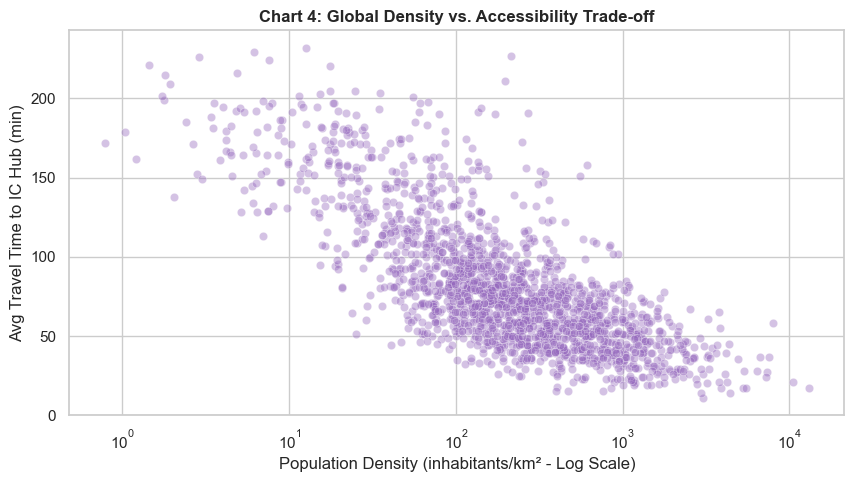

In [79]:
# 1. Filter dataset for complete demographic and accessibility records
density_df = df[(df['Pop_Density'].notna()) & 
                (df['avg_travel_time_ic'].notna()) & 
                (df['Pop_Density'] > 0)].copy()

all_cantons_in_data = sorted(density_df['canton'].unique())

# 2. Calculate Pearson correlation coefficients per canton
# We compute this dynamically to allow the D3.js frontend to display per-canton stats
canton_stats = {}

for canton in all_cantons_in_data:
    c_df = density_df[density_df['canton'] == canton]
    n_muni = len(c_df)
    r_val = None
    
    # Pearson requires at least 3 data points and non-zero variance
    if n_muni > 2 and c_df['Pop_Density'].std() > 0 and c_df['avg_travel_time_ic'].std() > 0:
        r_val, _ = pearsonr(c_df['Pop_Density'], c_df['avg_travel_time_ic'])
        
    canton_stats[canton] = {
        'r': float(r_val) if r_val is not None and not pd.isna(r_val) else None,
        'n': n_muni
    }

print("--- Chart 4: Density Trade-off Analysis ---")
print(f"Total Sample: {len(density_df)} municipalities across {len(all_cantons_in_data)} cantons.")
print("Per-canton correlation coefficients calculated.")

# 3. Export data to JSON for D3.js consumption
# Replace NaN with None (JSON-compatible null) to prevent frontend parsing errors
export_df4 = density_df[['name', 'canton', 'Pop_Density', 'avg_travel_time_ic', 'population']].replace({np.nan: None})

with open(output_dir / 'density_isolation.json', 'w', encoding='utf-8') as f:
    json.dump({
        'title': 'Density Trade-off',
        'n_data': len(density_df),
        'major_cantons': all_cantons_in_data,
        'canton_stats': canton_stats,  # Exported stats for frontend UI updates
        'data': export_df4.to_dict('records')
    }, f)

# 4. Inline visualization (Global overview for notebook validation)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=density_df, x='Pop_Density', y='avg_travel_time_ic', alpha=0.4, color='#9467bd')

# Use logarithmic scale on X-axis to normalize the extreme density range
plt.xscale('log') 
plt.title("Chart 4: Global Density vs. Accessibility Trade-off", fontweight='bold')
plt.xlabel("Population Density (inhabitants/km² - Log Scale)")
plt.ylabel("Avg Travel Time to IC Hub (min)")
plt.show()

## Summary

In [80]:
print("\n" + "="*40)
print("  PIPELINE EXECUTION COMPLETE  ")
print("="*40)
print(f"Data Source Validated : {len(df)} records")
print(f"Web Assets Exported   : {output_dir.absolute()}")
print("\nThe JSON payloads are now optimized, cleaned, and ready to be consumed by the D3.js dashboard interfaces.")


  PIPELINE EXECUTION COMPLETE  
Data Source Validated : 1830 records
Web Assets Exported   : /Users/matthiaswyss/Documents/EPFL/2025-26/MA4/COM-480 Data Visualization/les-vizionnaires.worktrees/agents-analysis-correlation-graphs-d3js/notebooks/../docs/data/correlations

The JSON payloads are now optimized, cleaned, and ready to be consumed by the D3.js dashboard interfaces.
